<a href="https://colab.research.google.com/github/CAB-21/Quish-Hunter-Network-Forensics-for-QR-Phishing-Cloud-Evasion/blob/main/NF_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install flask pyngrok qrcode[pil]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00


Setup the "Tunnel" (Ngrok)

In [ ]:
from pyngrok import ngrok

# 1. Authenticate (Paste your token below!)
ngrok.set_auth_token("38If2ObihXLpJBrlpcMcsNa0L04_32GUHFTHgT6ZzaXNrVd1h")

# 2. Kill any old tunnels if you re-run this cell
ngrok.kill()

# 3. Open a tunnel to port 5000 (where Flask will run)
# This gives us a public URL (e.g., https://1234-56-78.ngrok-free.app)
public_url = ngrok.connect(5000).public_url
print(f"✅ YOUR PUBLIC URL IS: {public_url}")

✅ YOUR PUBLIC URL IS: https://acrotic-ascertainably-angie.ngrok-free.dev


Generate the QR Code

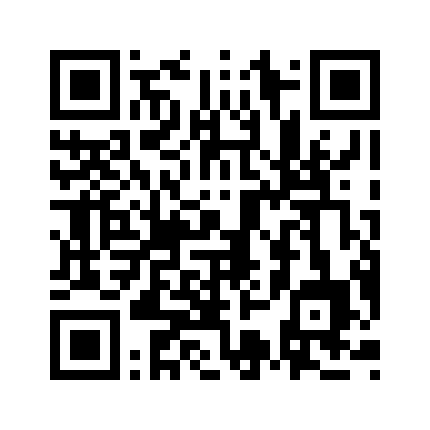

Scan this with your phone!


In [ ]:
import qrcode
from IPython.display import display

# PASTE THE PUBLIC URL FROM STEP 3 HERE
target_url = " https://acrotic-ascertainably-angie.ngrok-free.dev"

# Generate QR
qr = qrcode.QRCode(version=1, box_size=10, border=5)
qr.add_data(target_url)
qr.make(fit=True)
img = qr.make_image(fill='black', back_color='white')

# Show it right here in Colab
display(img)
print("Scan this with your phone!")

Run the Server

In [ ]:
from flask import Flask, redirect
import datetime

app = Flask(__name__)

# PASTE YOUR GOOGLE DRIVE LINK HERE (The malicious APK link)
DESTINATION_URL = "https://drive.google.com/file/d/150hXYnStK1q27SSWZ1cvPnIU7nFL8qQE/view?usp=sharing"

@app.route('/')
def home():
    print(f"\n[!] HIT DETECTED at {datetime.datetime.now()}!")
    return redirect(DESTINATION_URL, code=302)

if __name__ == '__main__':
    app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [15/Jan/2026 15:57:51] "GET / HTTP/1.1" 302 -



[!] HIT DETECTED at 2026-01-15 15:57:51.107396!


INFO:werkzeug:127.0.0.1 - - [15/Jan/2026 16:28:35] "GET / HTTP/1.1" 302 -



[!] HIT DETECTED at 2026-01-15 16:28:35.792179!


The Forensic Script

In [ ]:
# === STEP 1: INSTALL LIBRARIES ===
# (This installs Scapy and Requests if they are missing)
!pip install scapy requests

# === STEP 2: IMPORT & SETUP ===
import logging
# Suppress unnecessary warnings
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

from scapy.all import *
import requests
import os

print("\n[+] LIBRARIES READY. STARTING FORENSIC TOOL...")

# === STEP 3: DEFINE FUNCTIONS ===

def analyze_pcap(pcap_file):
    print(f"[*] Reading Capture File: {pcap_file}")

    # 1. Verify File Exists
    if not os.path.exists(pcap_file):
        print(f"[!] ERROR: File '{pcap_file}' not found.")
        print("    -> Make sure you uploaded it to the 'Files' folder on the left!")
        print("    -> Make sure the name matches exactly (case sensitive).")
        return []

    # 2. Read Packets
    try:
        packets = rdpcap(pcap_file)
    except Exception as e:
        print(f"[!] Error reading file. It might be corrupted or empty.\n    Error details: {e}")
        return []

    detected_shorteners = set()
    # List of common URL shorteners to hunt for
    shortener_domains = ["bit.ly", "tinyurl.com", "is.gd", "t.co", "goo.gl", "ngrok"]

    print(f"[*] Scanning {len(packets)} packets for suspicious DNS/HTTP traffic...")

    for pkt in packets:
        # Check for DNS Queries (UDP Port 53)
        if pkt.haslayer(DNS) and pkt.qr == 0:
            try:
                if pkt.haslayer(DNSQR):
                    query_name = pkt[DNSQR].qname.decode('utf-8').rstrip('.')
                    # Check if the domain matches our watchlist
                    for shortener in shortener_domains:
                        if shortener in query_name:
                            detected_shorteners.add(query_name)
            except:
                pass

    if detected_shorteners:
        print(f"\n[!] ALERT: SUSPICIOUS ACTIVITY DETECTED!")
        print(f"    Evidence found of communication with:")
        for domain in detected_shorteners:
            print(f"    -> {domain}")
    else:
        print("[-] No obvious DNS queries to standard shorteners found in this capture.")

    return list(detected_shorteners)

def trace_url(start_url):
    print(f"\n[*] INITIATING ACTIVE TRACE FOR: {start_url}")
    print("    (Mimicking Android Mobile Device User-Agent)")

    # Headers to make the server think we are a mobile phone
    headers = {
        'User-Agent': 'Mozilla/5.0 (Linux; Android 10; SM-G960F) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/77.0.3865.92 Mobile Safari/537.36'
    }

    try:
        # Follow the redirects
        response = requests.get(start_url, headers=headers, allow_redirects=True, timeout=10)

        print("\n--- REDIRECT CHAIN (The Path) ---")
        if response.history:
            for i, step in enumerate(response.history):
                print(f"Hop {i+1}: {step.url}  [Status: {step.status_code}]")
        else:
            print("No redirects found. Direct link.")

        final_url = response.url
        print(f"FINAL DESTINATION: {final_url}")

        # Check against threat indicators
        verify_threat(final_url)

    except Exception as e:
        print(f"[!] Trace Failed. The link might be dead or invalid.\n    Error: {e}")

def verify_threat(url):
    print("\n--- THREAT REPORT ---")
    score = 0

    # Indicator 1: Cloud Storage Abuse
    cloud_providers = ['drive.google.com', 'dropbox.com', 'onedrive.live.com', 'box.com']
    if any(provider in url for provider in cloud_providers):
        print("[!] RISK: Destination is a Cloud Storage Provider (Often used to bypass firewalls).")
        score += 1

    # Indicator 2: Dangerous File Types
    dangerous_exts = ['.apk', '.exe', '.sh', '.bat', '.ipa']
    if any(ext in url.lower() for ext in dangerous_exts):
        print("[!] CRITICAL: URL points to an Executable/Installer file.")
        score += 2

    if score >= 2:
        print("[!!!] VERDICT: HIGH LIKELIHOOD OF MALWARE DELIVERY (Quishing)")
    elif score == 1:
        print("[!] Verdict: SUSPICIOUS. Proceed with caution.")
    else:
        print("[+] Verdict: Destination appears benign.")

# === STEP 4: EXECUTION ===

# 1. Set the exact filename you saved
pcap_filename = "quishing_evidence.pcapng"

# 2. Run the Passive Analysis
found_domains = analyze_pcap(pcap_filename)

# 3. Ask for the Link to Trace
print("\n" + "="*50)
print("Analysis Phase 1 Complete.")
print("Now, paste the suspicious link (the one from your QR code) to trace the full attack chain.")
target_link = input("Enter the link (e.g., https://bit.ly/xyz): ")

if target_link:
    trace_url(target_link)


[+] LIBRARIES READY. STARTING FORENSIC TOOL...
[*] Reading Capture File: quishing_evidence.pcapng
[*] Scanning 2646 packets for suspicious DNS/HTTP traffic...

[!] ALERT: SUSPICIOUS ACTIVITY DETECTED!
    Evidence found of communication with:
    -> acrotic-ascertainably-angie.ngrok-free.dev
    -> acrotic-ascertainably-angie.ngrok-free.dev.mshome.net

Analysis Phase 1 Complete.
Now, paste the suspicious link (the one from your QR code) to trace the full attack chain.
Enter the link (e.g., https://bit.ly/xyz): https://bit.ly/3NkV9Lg

[*] INITIATING ACTIVE TRACE FOR: https://bit.ly/3NkV9Lg
    (Mimicking Android Mobile Device User-Agent)

--- REDIRECT CHAIN (The Path) ---
Hop 1: https://bit.ly/3NkV9Lg  [Status: 301]
FINAL DESTINATION: https://drive.google.com/file/d/150hXYnStK1q27SSWZ1cvPnIU7nFL8qQE/view?usp=sharing

--- THREAT REPORT ---
[!] RISK: Destination is a Cloud Storage Provider (Often used to bypass firewalls).
[!] Verdict: SUSPICIOUS. Proceed with caution.
